# StyleSync — Occasion Classifier v2 (Balanced Subset)

Mirrors `baseline_improved.ipynb`'s recipe but for the 3-class occasion task. Sampled to a balanced subset (500 per class = 1500 images) so training finishes in ~10-15 minutes instead of 90 — same approach that worked well for the category model.

**Why balanced subset (not full 23k):**
- Same data scale as `baseline_improved.ipynb` (which produced our 97.9% category model)
- Fast training, easier to iterate
- Don't need class-weighted loss — classes are already balanced
- Apply **prior correction** at deploy time to map back to the natural 77/15/8 occasion distribution (same trick we use for the category model)

**Recipe (identical to baseline_improved.ipynb):**
- ResNet-50, `layer4` unfrozen, new 3-way FC head
- 224×224 input, batch size 16, 20 epochs
- AdamW + weight decay, CosineAnnealingLR, augmentation, differential LRs
- Standard (unweighted) CrossEntropyLoss — data is already balanced
- Save best-val checkpoint to `models/resnet50_stylesync_occasion_v2.pt`

In [1]:
import sys, os, copy
from pathlib import Path
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
USAGE_TO_LABEL = {"Casual": 0, "Sports": 1, "Formal": 2}
LABEL_TO_USAGE = {v: k for k, v in USAGE_TO_LABEL.items()}
CLASS_NAMES    = [LABEL_TO_USAGE[i] for i in range(len(USAGE_TO_LABEL))]
NUM_CLASSES    = len(USAGE_TO_LABEL)

# Cap Casual at 2000; keep all Sports + Formal. ~6300 total, mild 1.4:2:1.4 imbalance.
CASUAL_CAP = 2000

### Build the balanced occasion subset

Pulls 500 per class from `combined_df.csv`, only rows whose image is already on disk in `data/images/raw_images/`. Saves the resulting balanced df to `data/balanced_occasion_df.csv` for reproducibility / teammate use.

In [3]:
IMG_DIR = Path("../data/images/raw_images")

full = pd.read_csv("../data/combined_df.csv")
full = full[full["usage"].isin(USAGE_TO_LABEL)].reset_index(drop=True)
full = full[full["id"].apply(lambda x: (IMG_DIR / f"{x}.jpg").exists())].reset_index(drop=True)

# Cap Casual at CASUAL_CAP, keep all Sports/Formal
parts = []
for usage in CLASS_NAMES:
    pool = full[full["usage"] == usage]
    if usage == "Casual":
        pool = pool.sample(n=min(CASUAL_CAP, len(pool)), random_state=42)
    parts.append(pool)

occasion_df = pd.concat(parts).reset_index(drop=True)
occasion_df.to_csv("../data/balanced_occasion_df.csv", index=False)

print(f"Occasion subset: {len(occasion_df)} samples")
print(occasion_df["usage"].value_counts())

Occasion subset: 7332 samples
usage
Sports    3558
Casual    2000
Formal    1774
Name: count, dtype: int64


In [4]:
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class WardrobeDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self.image_dir / f"{row['id']}.jpg"
        label = USAGE_TO_LABEL[row["usage"]]
        img   = Image.open(path).convert("RGB")
        return self.transform(img), label

In [5]:
train_df, val_df = train_test_split(
    occasion_df, test_size=0.2, random_state=42, stratify=occasion_df["usage"]
)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_dataset = WardrobeDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = WardrobeDataset(val_df,   IMG_DIR, transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

Train: 5865 | Val: 1467


In [6]:
model = models.resnet50(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Device: mps
Trainable params: 14,970,883 / 23,514,179 (63.7%)


In [7]:
NUM_EPOCHS = 20

criterion = nn.CrossEntropyLoss()   # no class weights — data is balanced

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ],
    weight_decay=1e-4,
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [8]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state   = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss / len(train_loader))
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = copy.deepcopy(model.state_dict())
        marker = "  *best*"
    else:
        marker = ""

    current_lr = scheduler.get_last_lr()[0]
    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f} | "
        f"LR(head): {current_lr:.2e}{marker}"
    )
    scheduler.step()

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.4845 | Train Acc: 0.8130 | Val Loss: 0.5217 | Val Acc: 0.7655 | LR(head): 1.00e-04  *best*
Epoch 02/20 | Train Loss: 0.3402 | Train Acc: 0.8788 | Val Loss: 0.3628 | Val Acc: 0.8759 | LR(head): 9.94e-05  *best*
Epoch 03/20 | Train Loss: 0.2888 | Train Acc: 0.8968 | Val Loss: 0.3229 | Val Acc: 0.8766 | LR(head): 9.76e-05  *best*
Epoch 04/20 | Train Loss: 0.2570 | Train Acc: 0.9100 | Val Loss: 0.2961 | Val Acc: 0.8971 | LR(head): 9.46e-05  *best*
Epoch 05/20 | Train Loss: 0.2176 | Train Acc: 0.9228 | Val Loss: 0.4585 | Val Acc: 0.8309 | LR(head): 9.05e-05
Epoch 06/20 | Train Loss: 0.1860 | Train Acc: 0.9327 | Val Loss: 0.3400 | Val Acc: 0.8937 | LR(head): 8.54e-05
Epoch 07/20 | Train Loss: 0.1493 | Train Acc: 0.9468 | Val Loss: 0.3770 | Val Acc: 0.8903 | LR(head): 7.94e-05
Epoch 08/20 | Train Loss: 0.1398 | Train Acc: 0.9500 | Val Loss: 0.3875 | Val Acc: 0.8821 | LR(head): 7.27e-05
Epoch 09/20 | Train Loss: 0.1210 | Train Acc: 0.9567 | Val Loss: 0.3650 | Val Ac

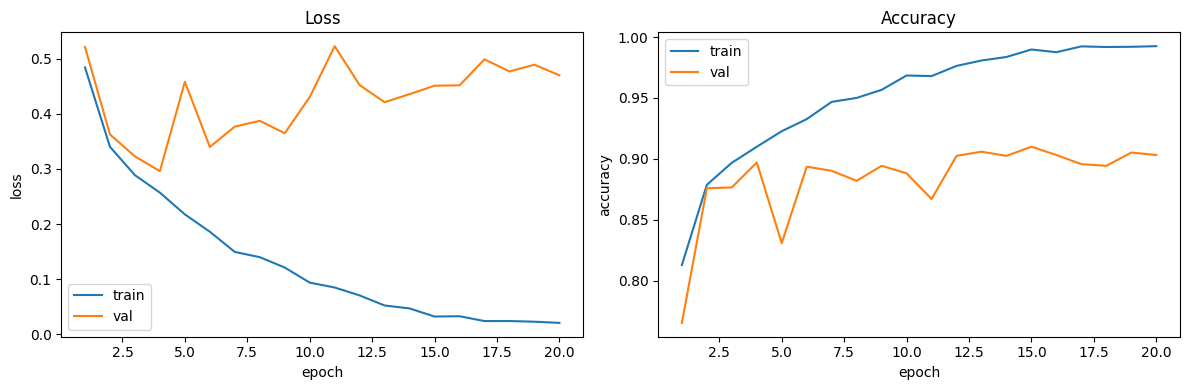

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs_x, history["train_loss"], label="train")
axes[0].plot(epochs_x, history["val_loss"],   label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs_x, history["train_acc"], label="train")
axes[1].plot(epochs_x, history["val_acc"],   label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

In [10]:
os.makedirs("../models", exist_ok=True)
out_path = "../models/resnet50_stylesync_occasion_v2.pt"
torch.save(best_state, out_path)
print(f"Best model (val_acc={best_val_acc:.4f}) saved to {out_path}")

Best model (val_acc=0.9100) saved to ../models/resnet50_stylesync_occasion_v2.pt


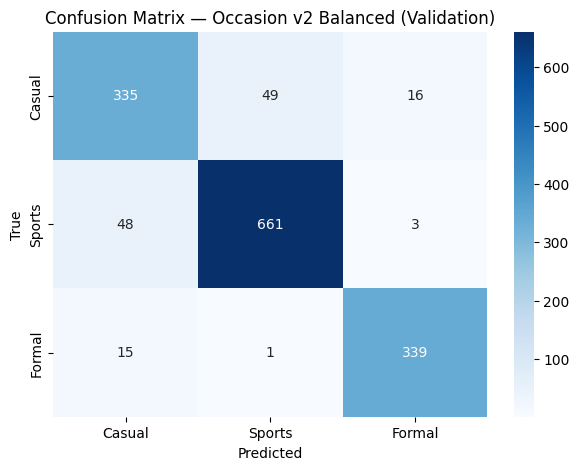

              precision    recall  f1-score   support

      Casual     0.8417    0.8375    0.8396       400
      Sports     0.9297    0.9284    0.9290       712
      Formal     0.9469    0.9549    0.9509       355

    accuracy                         0.9100      1467
   macro avg     0.9061    0.9069    0.9065      1467
weighted avg     0.9099    0.9100    0.9099      1467



In [11]:
model.load_state_dict(torch.load(out_path, map_location=device))
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device); labels = labels.to(device)
        preds  = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Occasion v2 Balanced (Validation)")
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))